<img src="https://iteso.mx/documents/27014/202031/Logo-ITESO-MinimoH.png"
     align="right"
     width="300"/>

# Práctica SARIMAX Predicción de pasajeros de avión

## *Modelos no lineales para pronósitico*  - Pedro Martinez

---

#

In [21]:
import pandas as pd
import numpy as np
import holidays
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import grangercausalitytests
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_ccf

In [9]:
# Cargamos los datos desde archico de TSA
file_path = "data/tsa.xlsx"
df = pd.read_excel(file_path)

# Convertimos a fechas
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').set_index('Date')

# Creamos la columna llena de ceros
df['Holiday_Dummy'] = 0
# Descargamos los holidays de USA de los años que hay en TSA
years = df.index.year.unique()
us_holidays = holidays.US(years=years)


# Lógica: Marcamos con 1 si la fecha cae en una ventana ALGUNOS días
for date in df.index:
    # Ventana de días
    window = pd.date_range(start=date - pd.Timedelta(days=1),
                           end=date + pd.Timedelta(days=1))

    # Si algún día de la ventana es festivo, marcamos el día actual como 1
    if any(d in us_holidays for d in window):
        df.loc[date, 'Holiday_Dummy'] = 1

In [10]:

# Graficamos las series de tiempo y la serie dummy de holidays
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Serie 1: Pasajeros (Línea Azul) - Eje Izquierdo
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df['Numbers'],
        name="Pasajeros",
        line=dict(color='#005EB8', width=1.5)
    ),
    secondary_y=False
)

# Serie 2: Dummy Festivos (Barras Rojas Transparentes) - Eje Derecho
fig.add_trace(
    go.Bar(
        x=df.index,
        y=df['Holiday_Dummy'],
        name="Día Festivo (Dummy)",
        marker_color='red',
        opacity=0.6 # Transparencia para ver la línea detrás
    ),
    secondary_y=True
)

# Diseño
fig.update_layout(
    title="Tráfico TSA vs Días Festivos (USA)",
    template="plotly_white",
    hovermode="x unified",
    legend=dict(orientation="h", y=1.02, x=1)
)

# Configuración de Ejes
fig.update_yaxes(title_text="Número de Pasajeros", secondary_y=False)
fig.update_yaxes(title_text="Indicador Festivo (0/1)", secondary_y=True, range=[0, 1.5], showgrid=False)

fig.show()

Resultados de Estacionariedad:
--- Prueba ADF para: Log Pasajeros (Sin diferenciar) ---
ADF Statistic: -5.4230
p-value: 0.0000
✅ La serie es ESTACIONARIA (Podemos modelar)


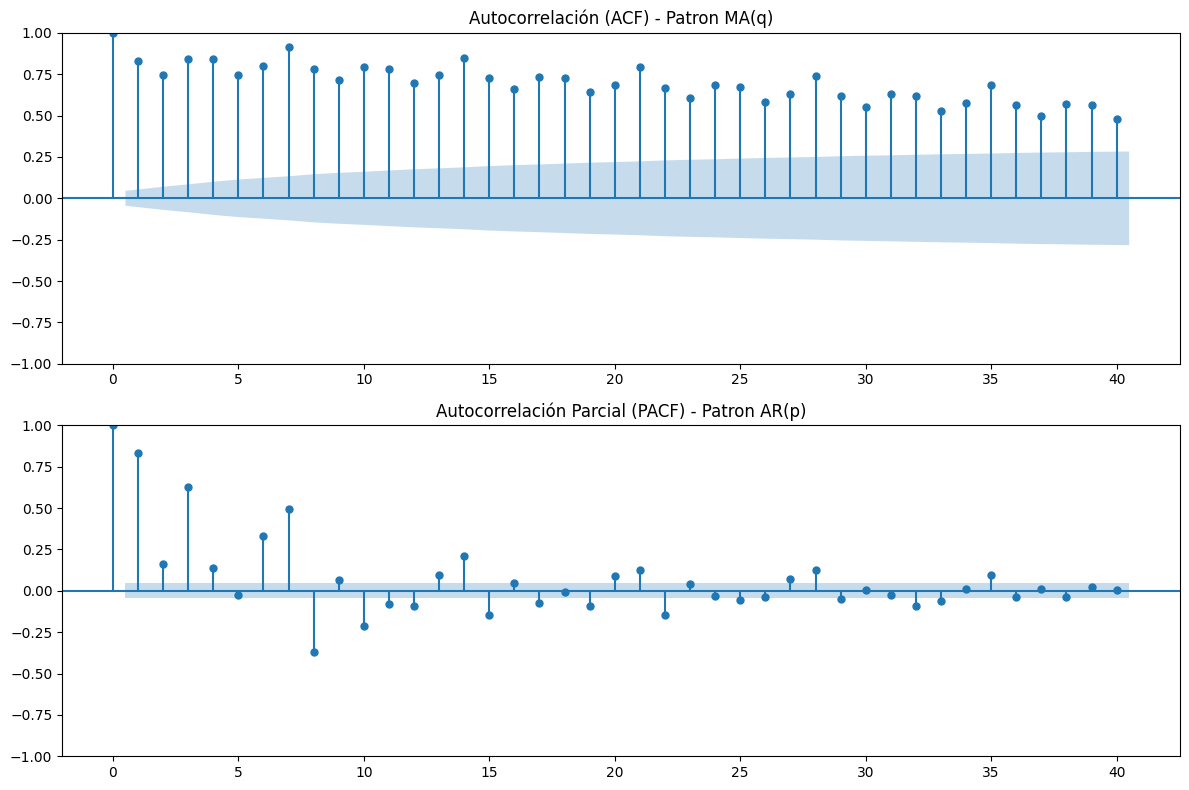

In [11]:

# Tranformamos pasajeros a log
df['Log_Passengers'] = np.log(df['Numbers'])

# Prueba de Dickey-Fuller Aumentada (ADF)
def run_adf(series, name):
    result = adfuller(series.dropna())
    print(f'--- Prueba ADF para: {name} ---')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    if result[1] < 0.05:
        print("✅ La serie es ESTACIONARIA (Podemos modelar)")
    else:
        print("❌ La serie NO es estacionaria (Necesita más diferenciación)")

print("Resultados de Estacionariedad:")
run_adf(df['Log_Passengers'], "Log Pasajeros (Sin diferenciar)")

# Usamos la serie diferenciada porque es la que entra al modelo
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(df['Log_Passengers'].dropna(), lags=40, ax=ax1, title="Autocorrelación (ACF) - Patron MA(q)")
plot_pacf(df['Log_Passengers'].dropna(), lags=40, ax=ax2, title="Autocorrelación Parcial (PACF) - Patron AR(p)")
plt.tight_layout()
plt.show()

Resultados de Estacionariedad:
--- Prueba ADF para: Log Pasajeros (Diferencia Semanal) ---
ADF Statistic: -7.6003
p-value: 0.0000
✅ La serie es ESTACIONARIA (Podemos modelar)


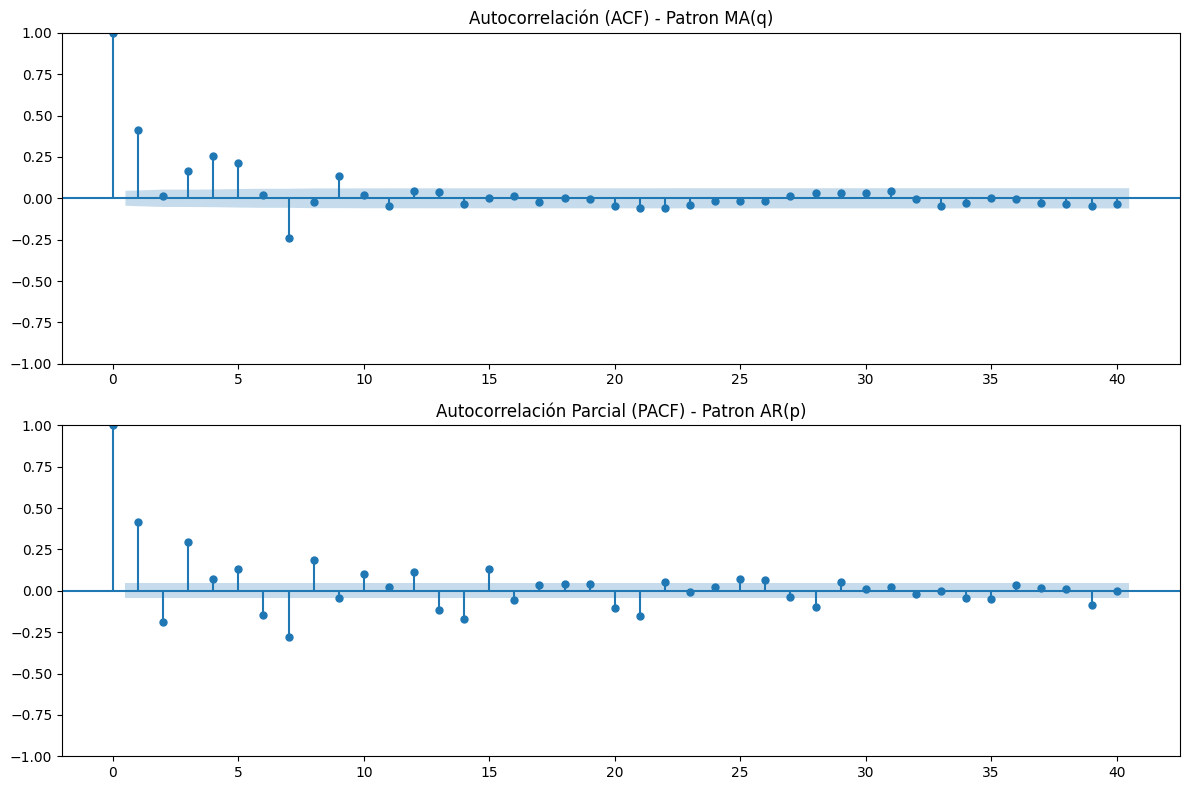

In [ ]:
# Diferenciación Estacional (Lag 7 para datos diarios)
# Restamos a hoy el valor de hace una semana
df['Diff_7'] = df['Log_Passengers'].diff(7).dropna()

print("Resultados de Estacionariedad:")
run_adf(df['Diff_7'], "Log Pasajeros (Diferencia Semanal)")

# Gráficas ACF y PACF
# Esto nos ayuda a elegir p y q del modelo
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
# Usamos la serie diferenciada porque es la que entra al modelo
plot_acf(df['Diff_7'].dropna(), lags=40, ax=ax1, title="Autocorrelación (ACF) - Patron MA(q)")
plot_pacf(df['Diff_7'].dropna(), lags=40, ax=ax2, title="Autocorrelación Parcial (PACF) - Patron AR(p)")
plt.tight_layout()
plt.show()



In [ ]:
# Creamos subplots: 1 fila, 2 columnas (Lado a Lado)
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Serie Original (Millones)", "Transformación Logarítmica"),
    horizontal_spacing=0.1 # Espacio entre las dos gráficas
)

# 1. Gráfica de la Serie Original (Izquierda)
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df['Numbers'],
        name="Original",
        line=dict(color='#005EB8', width=1)
    ),
    row=1, col=1
)

# 2. Gráfica de la Serie Logarítmica (Derecha)
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df['Log_Passengers'],
        name="Logaritmo",
        line=dict(color='#FF9900', width=1)
    ),
    row=1, col=2
)

# Ambas se mueven igual
fig.update_xaxes(matches='x')


fig.update_layout(
    title_text="<b>Comparativa Lado a Lado:</b> Efecto de la Estabilización de Varianza",
    template="plotly_white",
    showlegend=False,
    margin=dict(l=40, r=40, t=80, b=40) # Ajustar márgenes
)

# Etiquetas Eje Y
fig.update_yaxes(title_text="Pasajeros", row=1, col=1)
fig.update_yaxes(title_text="Log(Pasajeros)", row=1, col=2)

fig.show()

In [14]:


print("\n" + "="*50)
print("PRUEBA DE CAUSALIDAD DE GRANGER")
print("Hipótesis Nula (H0): Los días festivos NO causan cambios en el tráfico.")
print("Serie analizada: Log_Passengers (Sin Diff Estacional)")
print("="*50)

# Preparamos el DataFrame para la prueba
# La primera columna debe ser la serie TARGET
# La segunda columna debe ser la serie AYUDA
granger_data = df[['Log_Passengers', 'Holiday_Dummy']].dropna()

# Ejecutamos la prueba para los primeros 7 lags (días)
# verbose=True imprime los resultados detallados

granger_results = grangercausalitytests(granger_data, maxlag=7, verbose=True)


print("\n" + "="*50)
print("GUÍA DE INTERPRETACIÓN:")
print("Busca la fila 'ssr_ftest' y su columna 'p-value'.")
print("Si p < 0.05, estadísticamente la variable 'Holiday_Dummy' ayuda a predecir 'Log_Passengers'.")
print("="*50)


PRUEBA DE CAUSALIDAD DE GRANGER
Hipótesis Nula (H0): Los días festivos NO causan cambios en el tráfico.
Serie analizada: Log_Passengers (Sin Diff Estacional)

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.7037  , p=0.1920  , df_denom=1875, df_num=1
ssr based chi2 test:   chi2=1.7064  , p=0.1914  , df=1
likelihood ratio test: chi2=1.7057  , p=0.1916  , df=1
parameter F test:         F=1.7037  , p=0.1920  , df_denom=1875, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=5.6200  , p=0.0037  , df_denom=1872, df_num=2
ssr based chi2 test:   chi2=11.2701 , p=0.0036  , df=2
likelihood ratio test: chi2=11.2364 , p=0.0036  , df=2
parameter F test:         F=5.6200  , p=0.0037  , df_denom=1872, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=19.2241 , p=0.0000  , df_denom=1869, df_num=3
ssr based chi2 test:   chi2=57.8883 , p=0.0000  , df=3
likelihood ratio test: chi2=57.0131 , p=0.0000  , df=3
par

/home/sofi/Documents/vscode/archivos_mnlpp/.venv/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning:

verbose is deprecated since functions should not print results



In [15]:
print("\n" + "="*50)
print("PRUEBA DE CAUSALIDAD DE GRANGER")
print("Hipótesis Nula (H0): Los días festivos NO causan cambios en el tráfico.")
print("Serie analizada: Diff_7 (Sin Diff Estacional)")
print("="*50)

# Preparamos el DataFrame para la prueba
# La primera columna debe ser la serie TARGET
# La segunda columna debe ser la serie AYUDA
granger_data = df[['Diff_7', 'Holiday_Dummy']].dropna()

# Ejecutamos la prueba para los primeros 7 lags (días)
# verbose=True imprime los resultados detallados

granger_results = grangercausalitytests(granger_data, maxlag=7, verbose=True)


print("\n" + "="*50)
print("GUÍA DE INTERPRETACIÓN:")
print("Busca la fila 'ssr_ftest' y su columna 'p-value'.")
print("Si p < 0.05, estadísticamente la variable 'Holiday_Dummy' ayuda a predecir 'Diff_7'.")
print("="*50)


PRUEBA DE CAUSALIDAD DE GRANGER
Hipótesis Nula (H0): Los días festivos NO causan cambios en el tráfico.
Serie analizada: Diff_7 (Sin Diff Estacional)

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0812  , p=0.7757  , df_denom=1868, df_num=1
ssr based chi2 test:   chi2=0.0814  , p=0.7755  , df=1
likelihood ratio test: chi2=0.0814  , p=0.7755  , df=1
parameter F test:         F=0.0812  , p=0.7757  , df_denom=1868, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.8732  , p=0.4178  , df_denom=1865, df_num=2
ssr based chi2 test:   chi2=1.7510  , p=0.4167  , df=2
likelihood ratio test: chi2=1.7502  , p=0.4168  , df=2
parameter F test:         F=0.8732  , p=0.4178  , df_denom=1865, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=12.0468 , p=0.0000  , df_denom=1862, df_num=3
ssr based chi2 test:   chi2=36.2762 , p=0.0000  , df=3
likelihood ratio test: chi2=35.9286 , p=0.0000  , df=3
parameter F

/home/sofi/Documents/vscode/archivos_mnlpp/.venv/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning:

verbose is deprecated since functions should not print results



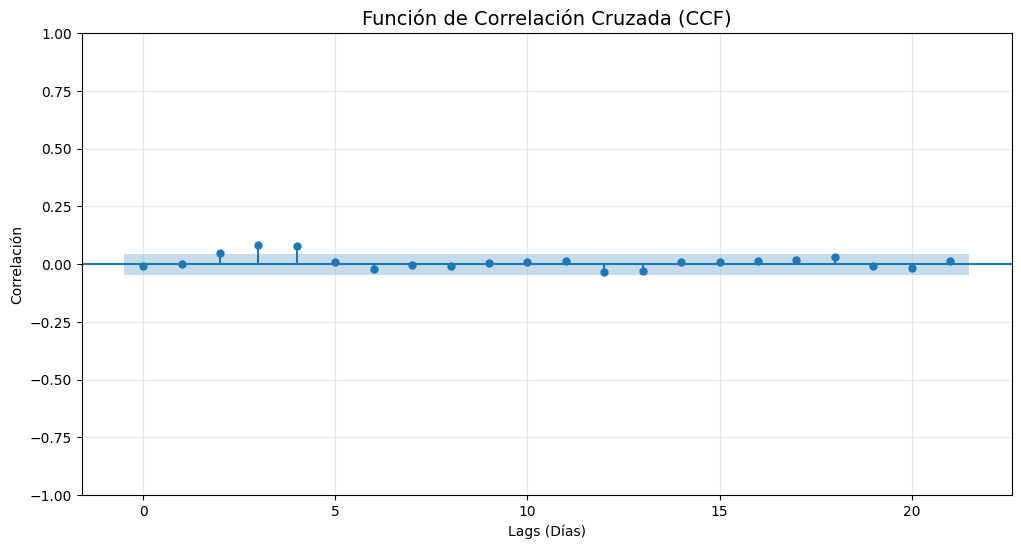

In [16]:


fig, ax = plt.subplots(figsize=(12, 6))

# lags=21 para ver el comportamiento de las últimas 3 semanas
plot_ccf(df['Holiday_Dummy'], df['Log_Passengers'], lags=21, ax=ax, alpha=0.05)

plt.title("Función de Correlación Cruzada (CCF)", fontsize=14)
plt.xlabel("Lags (Días)")
plt.ylabel("Correlación")
plt.grid(alpha=0.3)
plt.show()

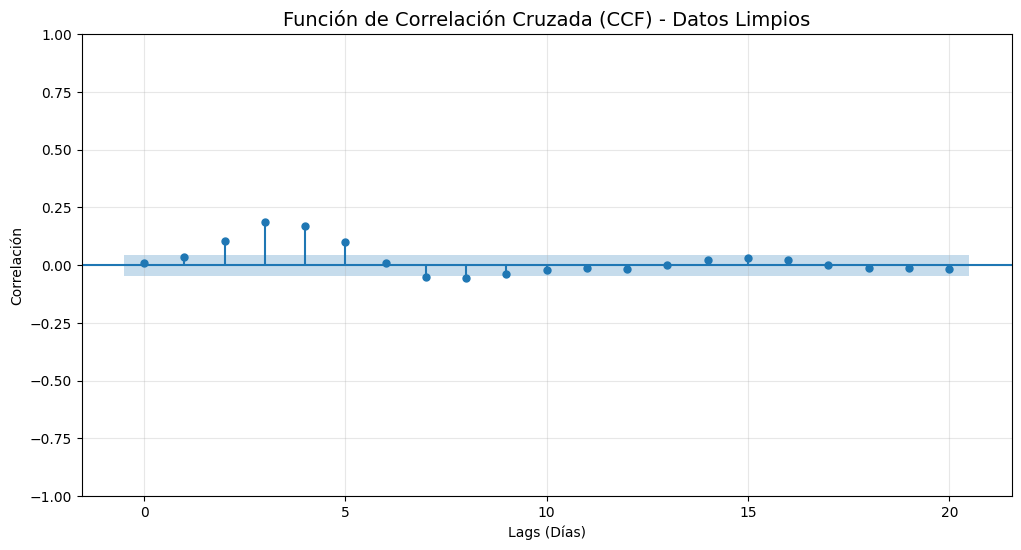

In [17]:
ccf_data = df[['Diff_7', 'Holiday_Dummy']].dropna()


fig, ax = plt.subplots(figsize=(12, 6))

# Importante: Usamos las series limpias (sin NaNs)
# Ponemos Holiday_Dummy primero para ver cómo afecta a los Pasajeros (Diff_7)
plot_ccf(ccf_data['Holiday_Dummy'], ccf_data['Diff_7'], lags=20, ax=ax, alpha=0.05)

plt.title("Función de Correlación Cruzada (CCF) - Datos Limpios", fontsize=14)
plt.xlabel("Lags (Días)")
plt.ylabel("Correlación")
plt.grid(alpha=0.3)
plt.show()


In [18]:

# Definimos el punto de corte para entrenamiento
train_size = int(len(df) * 0.9)
train, test = df.iloc[:train_size], df.iloc[train_size:]

# Definimos variables Endógenas (Y) y Exógenas (X)
y_train = train['Log_Passengers']
X_train = train[['Holiday_Dummy']]

y_test = test['Log_Passengers']
X_test = test[['Holiday_Dummy']]




# Configuramos el modelo considerando la estacionalidad de 7 días
model = sm.tsa.SARIMAX(
    y_train,
    exog=X_train,
    order=(3, 0, 1),              # (p, d, q)
    seasonal_order=(3, 0, 1, 7),  # (P, D, Q, s)
)

results = model.fit(disp=False)

# Imprimimos el resumen estadístico
print(results.summary())


# Predicción sobre el set de prueba
forecast_obj = results.get_forecast(steps=len(test), exog=X_test)
forecast_log = forecast_obj.predicted_mean

# Revertimos el Logaritmo para volver a la escala original (Pasajeros)
pred_real = np.exp(forecast_log)

fig = go.Figure()

# Todo el historial de entrenamiento
fig.add_trace(go.Scatter(
    x=train.index, y=train['Numbers'],
    name="Historial (Train)",
    line=dict(color='gray', width=1)
))

# Datos reales de prueba (para comparar)
fig.add_trace(go.Scatter(
    x=test.index, y=test['Numbers'],
    name="Realidad (Test)",
    line=dict(color='black', width=2)
))

# Predicciones del modelo
fig.add_trace(go.Scatter(
    x=test.index, y=pred_real,
    name="Predicción SARIMAX",
    line=dict(color='red', dash='dot', width=2)
))

fig.update_layout(
    title="Validación del Modelo SARIMAX: Historial Completo vs Predicciones",
    xaxis_title="Fecha",
    yaxis_title="Cantidad de Pasajeros",
    hovermode="x unified"
)

fig.show()

# Métrica de desempeño
mape = np.mean(np.abs((test['Numbers'] - pred_real) / test['Numbers'])) * 100
print(f"Error Porcentual Medio Absoluto (MAPE): {mape:.2f}%")

/home/sofi/Documents/vscode/archivos_mnlpp/.venv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/home/sofi/Documents/vscode/archivos_mnlpp/.venv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/home/sofi/Documents/vscode/archivos_mnlpp/.venv/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



                                     SARIMAX Results                                     
Dep. Variable:                    Log_Passengers   No. Observations:                 1691
Model:             SARIMAX(3, 0, 1)x(3, 0, 1, 7)   Log Likelihood                1856.962
Date:                           Mon, 23 Feb 2026   AIC                          -3693.925
Time:                                   20:23:34   BIC                          -3639.594
Sample:                               01-01-2021   HQIC                         -3673.806
                                    - 08-18-2025                                         
Covariance Type:                             opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Holiday_Dummy    -0.0318      0.005     -6.329      0.000      -0.042      -0.022
ar.L1            -0.1779      0.02

Error Porcentual Medio Absoluto (MAPE): 9.66%


In [19]:
# Creamos la nueva columna con el desplazamiento (Shift) hacia el futuro

df['Holiday_Lag'] = df['Holiday_Dummy'].shift(2)
df['Holiday_Lag'] = df['Holiday_Lag'].fillna(0)


# Definimos el set de exógenas
# Se puede usar solo el Lag3 o ambas
exog_cols = ['Holiday_Dummy', 'Holiday_Lag']

# Definimos el punto de corte para entrenamiento
train_size = int(len(df) * 0.9)
train, test = df.iloc[:train_size], df.iloc[train_size:]

# Definimos variables Endógenas (Y) y Exógenas (X)
y_train = train['Log_Passengers']
X_train = train[exog_cols]

y_test = test['Log_Passengers']
X_test = test[exog_cols]


# Configuramos el modelo considerando la estacionalidad de 7 días
model = sm.tsa.SARIMAX(
    y_train,
    exog=X_train,
    order=(3, 0, 1),              # (p, d, q)
    seasonal_order=(3, 0, 1, 7),  # (P, D, Q, s)
)

results = model.fit(disp=False, method='powell')

# Imprimimos el resumen estadístico
print(results.summary())


# Predicción sobre el set de prueba
forecast_obj = results.get_forecast(steps=len(test), exog=X_test)
forecast_log = forecast_obj.predicted_mean

# Revertimos el Logaritmo para volver a la escala original (Pasajeros)
pred_real = np.exp(forecast_log)

fig = go.Figure()

# Todo el historial de entrenamiento
fig.add_trace(go.Scatter(
    x=train.index, y=train['Numbers'],
    name="Historial (Train)",
    line=dict(color='gray', width=1)
))

# Datos reales de prueba
fig.add_trace(go.Scatter(
    x=test.index, y=test['Numbers'],
    name="Realidad (Test)",
    line=dict(color='black', width=2)
))

# Predicciones del modelo
fig.add_trace(go.Scatter(
    x=test.index, y=pred_real,
    name="Predicción SARIMAX",
    line=dict(color='red', dash='dot', width=2)
))

fig.update_layout(
    title="Validación del Modelo SARIMAX: Historial Completo vs Predicciones",
    xaxis_title="Fecha",
    yaxis_title="Cantidad de Pasajeros",
    hovermode="x unified"
)

fig.show()

# Métrica de desempeño
mape = np.mean(np.abs((test['Numbers'] - pred_real) / test['Numbers'])) * 100
print(f"Error Porcentual Medio Absoluto (MAPE): {mape:.2f}%")


/home/sofi/Documents/vscode/archivos_mnlpp/.venv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/home/sofi/Documents/vscode/archivos_mnlpp/.venv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.



                                     SARIMAX Results                                     
Dep. Variable:                    Log_Passengers   No. Observations:                 1691
Model:             SARIMAX(3, 0, 1)x(3, 0, 1, 7)   Log Likelihood                2202.072
Date:                           Mon, 23 Feb 2026   AIC                          -4382.144
Time:                                   20:24:02   BIC                          -4322.380
Sample:                               01-01-2021   HQIC                         -4360.013
                                    - 08-18-2025                                         
Covariance Type:                             opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Holiday_Dummy    -0.0181      0.006     -3.246      0.001      -0.029      -0.007
Holiday_Lag       0.0262      0.00

Error Porcentual Medio Absoluto (MAPE): 10.50%


In [20]:
# Creamos la nueva columna con el desplazamiento (Shift) hacia el futuro

df['Holiday_Lag3'] = df['Holiday_Dummy'].shift(3)
df['Holiday_Lag3'] = df['Holiday_Lag3'].fillna(0)


# Definimos el set de exógenas
# Se puede usar solo el Lag3 o ambas
exog_cols = ['Holiday_Lag3']

# Definimos el punto de corte para entrenamiento
train_size = int(len(df) * 0.9)
train, test = df.iloc[:train_size], df.iloc[train_size:]

# Definimos variables Endógenas (Y) y Exógenas (X)
y_train = train['Log_Passengers']
X_train = train[exog_cols]

y_test = test['Log_Passengers']
X_test = test[exog_cols]


# Configuramos el modelo considerando la estacionalidad de 7 días
model = sm.tsa.SARIMAX(
    y_train,
    exog=X_train,
    order=(3, 0, 1),              # (p, d, q)
    seasonal_order=(3, 0, 1, 7),  # (P, D, Q, s)
)

results = model.fit(disp=False, method='powell')

# Imprimimos el resumen estadístico
print(results.summary())


# Predicción sobre el set de prueba
forecast_obj = results.get_forecast(steps=len(test), exog=X_test)
forecast_log = forecast_obj.predicted_mean

# Revertimos el Logaritmo para volver a la escala original (Pasajeros)
pred_real = np.exp(forecast_log)

fig = go.Figure()

# Todo el historial de entrenamiento
fig.add_trace(go.Scatter(
    x=train.index, y=train['Numbers'],
    name="Historial (Train)",
    line=dict(color='gray', width=1)
))

# Datos reales de prueba (para comparar)
fig.add_trace(go.Scatter(
    x=test.index, y=test['Numbers'],
    name="Realidad (Test)",
    line=dict(color='black', width=2)
))

# Predicciones del modelo
fig.add_trace(go.Scatter(
    x=test.index, y=pred_real,
    name="Predicción SARIMAX",
    line=dict(color='red', dash='dot', width=2)
))

fig.update_layout(
    title="Validación del Modelo SARIMAX: Historial Completo vs Predicciones",
    xaxis_title="Fecha",
    yaxis_title="Cantidad de Pasajeros",
    hovermode="x unified"
)

fig.show()

# Métrica de desempeño
mape = np.mean(np.abs((test['Numbers'] - pred_real) / test['Numbers'])) * 100
print(f"Error Porcentual Medio Absoluto (MAPE): {mape:.2f}%")

/home/sofi/Documents/vscode/archivos_mnlpp/.venv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/home/sofi/Documents/vscode/archivos_mnlpp/.venv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.



                                     SARIMAX Results                                     
Dep. Variable:                    Log_Passengers   No. Observations:                 1691
Model:             SARIMAX(3, 0, 1)x(3, 0, 1, 7)   Log Likelihood                2192.096
Date:                           Mon, 23 Feb 2026   AIC                          -4364.193
Time:                                   20:24:34   BIC                          -4309.862
Sample:                               01-01-2021   HQIC                         -4344.074
                                    - 08-18-2025                                         
Covariance Type:                             opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Holiday_Lag3     0.0046      0.007      0.671      0.502      -0.009       0.018
ar.L1            1.1225      0.024   

Error Porcentual Medio Absoluto (MAPE): 10.78%
